# Laboratorium 10 - Warstwy Transformer


Na tym laboratorium zapoznamy się z warstwami Transformer i koncepcją hooks - funkcji, które jesteśmy w stanie "podłączyć" do istniejącego modelu na przejściowych warstwach przetwarzania.

Transformery to warstwy oparte o moduł uwagi. Koncepcja "uwagi" w sieciach głębokich to próba przetwarzania złożonych zależności w **zbiorach** obiektów - niekoniecznie sekwencjach, ale jest to jedno z typowych zastosowań.

Przykładowo, w przetwarzaniu zdania w języku naturalnym mamy problem ze złożonością naturalnej gramatyki, bo zależności niekoniecznie będą działały na zasadzie "każde słowo wpływa tylko na kolejne, następujące po nim słowo" (a wtedy nawięcej sensu miałoby działanie na zasadzie czystej rekurencji).

Zamiast tego, wykorzystanie uwagi oznacza, że przetwarzając słowo, możemy zwrócić **uwagę** na inne słowa **które są dla niego istotne**. Moduł uwagi musi się więc wyuczyć informacji o tym, które słowa są istotne dla siebie nawzajem. W najprostszej implementacji oznacza to porównywanie **każdego słowa z każdym**.

# Warstwa Transformer

Przyjrzyjmy się wewnętrznej strukturze warstwy Transformer:

In [12]:
import torch

transformer = torch.nn.Transformer(d_model=10, nhead=1)

print(transformer)

Transformer(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=10, out_features=10, bias=True)
        )
        (linear1): Linear(in_features=10, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=10, bias=True)
        (norm1): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=10, out_featu

/Users/malwina.juchiewicz/Desktop/SI/glebokie-sieci-neuronowe/laby/glebokie-sieci-env/lib/python3.10/site-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Ta implementacja podąża za oryginalną strukturą z *Attention is All You Need*, więc rozdziela enkodery i dekodery (ponieważ ta publikacja działała na problemie automatycznego tłumaczenia, gdzie potrzebna jest uwaga ze zdania wyjściowego na inne zdanie wejściowe), ma wiele dodatkowych operacji liniowych, LayerNorm, etc.

Sednem transformerów jest jednak operacja uwagi. Uwaga oparta o moduły self-attention (nazwę transformer w zasadzie mozna zastosować do dowolnych sieci opierających się o ten moduł) daje sieciom głębokim możliwość dopasowania do wielu typów danych w kórych zachodzą relacje między elementami: sekwencji (relacje w czasie), grafów (połączenia), obrazów (relacje pozycyjne w przestrzeni 2d), języka naturalnego (gramatyka) etc. Dzieje się tak, ponieważ bazowy mechanizm to po prostu porównanie każdy-z-każdym, a konkretną topologię problemu dodajemy przez inne mechanizmy, takie jak positional embedding i maskowanie.

# Zasada działania self-attention

Chcemy żeby każdy z elementów sekwencji "zapytał" (**query**) pozostałe elementy o to jak pozostałe elementy są **istotne dla niego**.

Aby to zapytanie miało sens, nasz element potrzebuje też jakiejś reprezentacji mówiącej relewantności dla innnych "pytających" elementów (**key**). W oparciu o to, możemy mnożąc macierze otrzymać macierz `liczba_elementów x liczba_elementów`. Następnie wykonamy na niej operację softmax. W ten sposób każdy element otrzymuj swoje "wagi uwagi" odnośnie wszystkich pozostałych elementów, które dzięki softmaxowi sumują się do jedynki.

Mając takie wagi, możemy zsumować reprezentacje pozostałych elementów wymnożone przez ich wagi. Ponieważ wynik tej operacji ma już iść dalej, a reprezentacje query i key służyły głównie do ustalania istotności elementów względem siebie nawzajem, stworzymy trzecią reprezentację elementów na potrzeby samego sumowania (**value**). W kodzie, dla uproszczenia bez batchowania danych:

In [13]:
sequence = torch.zeros((100,5))

query_projection = torch.nn.Linear(5,3)
key_projection = torch.nn.Linear(5,3)
value_projection = torch.nn.Linear(5,3)


q = query_projection(sequence)
k = key_projection(sequence)
v = value_projection(sequence)

attention = torch.nn.functional.softmax(q @ k.T, dim=-1)

print(attention.shape)

output = attention @ v

print(output.shape)

torch.Size([100, 100])
torch.Size([100, 3])


# Positional Embedding

O ile transformer osiągają imponujące wyniki w zadaniach sekwencyjnych, warto zwrócić uwagę, że zależności sekwencyjne nie są wbudowane w opisaną wyżej architekturę self-attention tak jak zależność, że krok n następuje po n-1 w sieciach rekurencyjnych, czy zależnoci pozycyjne w opercję konwolucji. Możemy wymusić, aby dla zadań predykcyjnych krok czasowy n nie widział króków n+1 i dalszych, ale sąsiedztwo w czasie w dalszym ciągu nie ma odzwierciedlenia w architekturze.

Istnieje bardzo proste rozwiązanie: dodajemy pozycję w sekwencji jako zmienną wejściową. Nie zawsze jest to reprezentacja dosłownie wyrażająca pozycje jako liczbę całkowitą - indeks, ale idea sprowadza się do dodania osadzenia pozycji wejściowej do naszych danych. Osadzenie można uzyskać z apomocą warstwy Mebedding, poznanej w poprzednim zadaniu.

Bardziej zaawansowane mechanizmy wykorzystują dodawanie informacji o pozycji na poziomie mechanizmu uwagi, modifikując wynik operacji mnożenia Q przez K, co pozwala uwzględnić informację o relatywnej pozycji.

## Zadanie 1

Przeprowadź trening sieci złożonej z trzech warstw TransformerEncoderLayer (w torch.nn) na zbiorach z poprzedniego zadania. Użyj jednej z opisanych wyżej wersji positional embedding. Dla klasyfikacji, dodaj osobny token na początku każdego zdania (tak aby sam w sobie nie był słowem).

In [14]:
import os
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm.notebook import tqdm
from tensorflow.keras.datasets import imdb
import matplotlib.pyplot as plt

In [15]:
VOCAB_SIZE = 10000 # najczesciej wystepujace slowa, ktore uwzgledniamy w naszym modelu
MAX_LEN    = 300 # maks dlugosc sekwencji, ktora bierzemy pod uwage
 
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    path='imdb.npz',
    num_words=None,
    skip_top=0,
    maxlen=None,
    seed=113,
    start_char=1,
    oov_char=2,
    index_from=3
)
 
x_train = [[token if token < VOCAB_SIZE else 2 for token in seq[:MAX_LEN]] for seq in x_train]
x_test  = [[token if token < VOCAB_SIZE else 2 for token in seq[:MAX_LEN]] for seq in x_test]
 
print(f"Train: {len(x_train)} przykładów")
print(f"Test:  {len(x_test)} przykładów")
print(f"Przykładowa sekwencja (pierwsze 10 tokenów): {x_train[0][:10]}")

Train: 25000 przykładów
Test:  25000 przykładów
Przykładowa sekwencja (pierwsze 10 tokenów): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]


In [ ]:
# === DATASET I DATALOADER ===
# IMDBDataset: opakowuje listę tokenów i etykiet w format PyTorch Dataset
# collate_transformer: sklejanie próbek w batch
#   - dodaje specjalny token [CLS] na początku każdego zdania (token klasyfikacji)
#   - pad_sequence: wyrównuje sekwencje do tej samej długości zerami
#   - mask: mówi transformerowi, które pozycje to padding (True = ignoruj)

BATCH_SIZE = 64
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
 
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.long)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        # zwracamy sekwencje i etykiete jako tensory
        return x, label
 
 
def collate_transformer(batch):
    sequences, labels = zip(*batch)
 
    CLS_ID = VOCAB_SIZE 
 
    sequences_with_cls = [
        torch.cat([torch.tensor([CLS_ID]), seq])
        for seq in sequences
    ]

    # dodaje zera na koniec krotszych sekwencji, zeby wszystkie mialy taka sama dlugosc
    padded = pad_sequence(sequences_with_cls, batch_first=True, padding_value=0)

    mask = (padded == 0)  
 
    return padded, mask, torch.stack(list(labels))
 
 
train_dataset = IMDBDataset(x_train, y_train)
test_dataset  = IMDBDataset(x_test,  y_test)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_transformer)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_transformer)
 

In [ ]:
# === ARCHITEKTURA MODELU ===
# token_embedding: zamienia indeksy słów na wektory d_model-wymiarowe
# pos_embedding: dodaje informację o pozycji tokenu w sekwencji (positional encoding)
# TransformerEncoderLayer: jedna warstwa transformera (self-attention + FFN + LayerNorm)
# TransformerEncoder: stos num_layers warstw enkodera
# classifier: warstwa liniowa zamieniająca reprezentację [CLS] na predykcję klasy

# forward():
#   positions: indeksy 0,1,2,...,seq_len-1 dla każdego elementu w batchu
#   token_embedding + pos_embedding: łączymy reprezentację słowa z jego pozycją
#   src_key_padding_mask: przekazujemy maskę paddingu do transformera
#   x[:, 0, :]: bierzemy tylko wyjście pierwszego tokenu ([CLS]) do klasyfikacji

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, num_classes,
                 max_len=MAX_LEN + 1, dropout=0.1):
        super().__init__()
 
        self.token_embedding = nn.Embedding(vocab_size + 1, d_model, padding_idx=0)
 
        self.pos_embedding = nn.Embedding(max_len, d_model)
 
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
 
        self.classifier = nn.Linear(d_model, num_classes)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, x, key_padding_mask=None):
        batch_size, seq_len = x.shape
 
        positions = torch.arange(seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, -1) 
 
        x = self.token_embedding(x) + self.pos_embedding(positions)
        x = self.dropout(x)
 
        x = self.transformer(x, src_key_padding_mask=key_padding_mask) 
 
        cls_output = x[:, 0, :]
 
        return self.classifier(cls_output)
 

In [ ]:
# === PĘTLA TRENINGOWA ===
# clip_grad_norm_: obcina gradienty do normy 1.0 – zapobiega eksplodującym gradientom
# history: słownik zapisujący metryki z każdej epoki
# best_val_loss: zapisujemy tylko najlepszy model (early saving)
# torch.save: checkpoint z wagami modelu

def train_transformer(model, train_loader, val_loader, epochs=5, lr=1e-3, device='cpu'):
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_val_loss = float('inf')
    os.makedirs('models', exist_ok=True)

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]", leave=False)
        for tokens, mask, labels in pbar:
            tokens = tokens.to(device)
            mask   = mask.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(tokens, key_padding_mask=mask)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total
        
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for tokens, mask, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [val]", leave=False):
                tokens = tokens.to(device)
                mask   = mask.to(device)
                labels = labels.to(device)

                outputs  = model(tokens, key_padding_mask=mask)
                loss     = criterion(outputs, labels)
                val_loss += loss.item()
                preds     = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc  = val_correct / val_total

        for k, v in zip(['train_loss', 'train_acc', 'val_loss', 'val_acc'],
                        [train_loss,   train_acc,   val_loss,   val_acc]):
            history[k].append(v)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'models/transformer_best.pt')
            best_str = '  ← best'
        else:
            best_str = ''

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}{best_str}")

    print(f"\nBest val loss: {best_val_loss:.4f} → models/transformer_best.pt")
    return history
 
 
def plot_history(history, title='Transformer'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    for ax, metric in zip(axes, ['loss', 'acc']):
        ax.plot(epochs, history[f'train_{metric}'], '--', label='train')
        ax.plot(epochs, history[f'val_{metric}'],   '-',  label='val')
        ax.set_title(f'{title} — {metric}')
        ax.legend(); ax.set_xlabel('Epoch')
    plt.tight_layout(); plt.show()

Parametry modelu: 1,913,730


Epoch 1/10 | Train loss: 0.5542, acc: 0.7099 | Val loss: 0.4463, acc: 0.8183  ← best


Epoch 2/10 | Train loss: 0.3820, acc: 0.8340 | Val loss: 0.3945, acc: 0.8309  ← best


Epoch 3/10 | Train loss: 0.3103, acc: 0.8714 | Val loss: 0.3569, acc: 0.8577  ← best


Epoch 4/10 | Train loss: 0.2703, acc: 0.8915 | Val loss: 0.3651, acc: 0.8618


...

Epoch 6/10 | Train loss: 0.2171, acc: 0.9176 | Val loss: 0.3688, acc: 0.8680


Epoch 7/10 | Train loss: 0.1954, acc: 0.9257 | Val loss: 0.4673, acc: 0.8660


Epoch 8/10 | Train loss: 0.1740, acc: 0.9350 | Val loss: 0.4103, acc: 0.8645


Epoch 9/10 | Train loss: 0.1603, acc: 0.9404 | Val loss: 0.4386, acc: 0.8652


Epoch 10/10 | Train loss: 0.1454, acc: 0.9481 | Val loss: 0.4219, acc: 0.8609

Best val loss: 0.3283 → models/transformer_best.pt


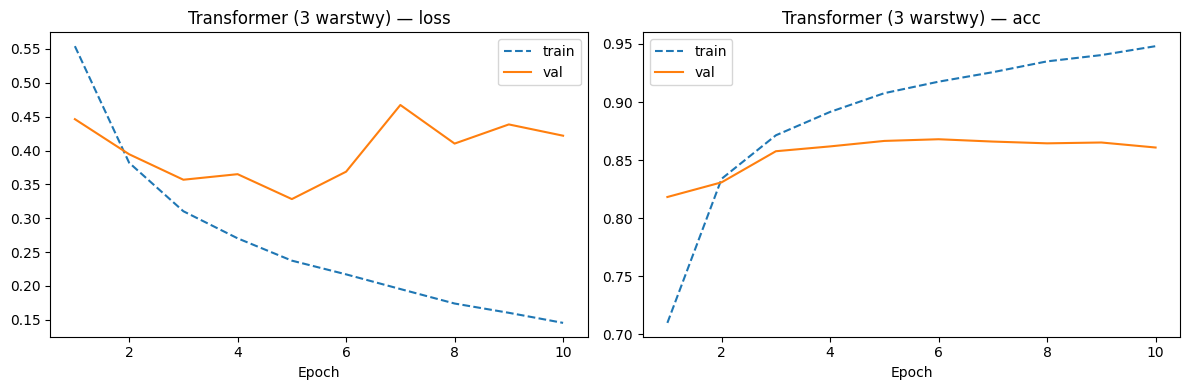

In [17]:
D_MODEL    = 128
NHEAD      = 8
NUM_LAYERS = 3
NUM_CLASSES = 2
EPOCHS     = 10
 
model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=0.2
)
 
print(f"Parametry modelu: {sum(p.numel() for p in model.parameters()):,}")

from tqdm.auto import tqdm
 
history = train_transformer(model, train_loader, test_loader, epochs=EPOCHS, lr=1e-3, device=DEVICE)
plot_history(history, title='Transformer (3 warstwy)')

## Pytorch hooks

Działając z głębokimi sieciami, często korzystać będziemy z gotowych modeli, a jeżeli chcielibyśmy spojrzeć na to, co dzieje się wewnątrz sieci, próba napisania od nowa własnego `forward` które weźmie to pod uwagę nie jest wygodnym rozwiązaniem.

Domyślna klasa reprezentująca warstwę w torchu, czyli `torch.nn.Module`, oferuje nam możliwość wstrzyknięcia własnego kodu zarówno w `forward`, jak i `backward` poprzez rejestrację hooków. Są to funkcje, które automatycznie wywołają się na wejściu, wyjściu lub gradiencie przy przetwarzaniu danych przez tenże moduł.

Dokładniej, dostępne są możliwości:


*   `register_forward_pre_hook` pozwala modyfikować dane przed wywołaniem `forward` modułu, można ustawić flagę `with_kwargs=True` żeby modyfikować też paramtery nazwane (przyda się w zadaniu 2).

      Funkcja podana jako hook powinna mieć format:

      `hook(module, args) -> None or modified_input`

      lub jeśli `use_kwargs=True`

      `hook(module, args, kwargs) -> None or (modified_input, kwargs)`

*   `register_forward_hook` pozwala nam zmodyfikować wyjście po `forward`, analogicznie można ustawić `with_kwargs=True` aby podejrzeć parametry nazwane, ale nie aby je zmodyfikować

*   `register_full_backward_hook` oraz `register_full_backward_pre_hook` w analogiczny sposób dają nam dostęp do gradientu po wyjściach/wejściach do modułu przy wywołaniu `backward`

Po wykorzystaniu hooks, jeżeli chcemy je usunąć przed dalszym korzystaniem z modelu, możemy skorzystać z obiektu `RemovableHandle` zwracanego przez powyższe funkcje.

In [19]:
linear = torch.nn.Linear(5,1)

data_batch = torch.zeros((10,5))
data_batch.requires_grad = True


def input_modifying_hook(module, input):
  print('pre-hook print:\n', input)
  return input[0] + 1

def output_modifying_hook(module, input, output):
  print('forward hook print:\n', input)
  return output + 1


def gradient_printing_hook(module, grad_input, grad_output):
  print('gradient hook print:\n', grad_input)
  return None

def not_firing_hook(module, grad_input, grad_output):
  print('THIS WILL NOT BE PRINTED')
  return None


# na wejściu podajemy zera, więc wyjście powinno być rónwe biasowi
print('layer bias:\n', linear.bias)
print('output without hooks:\n', linear(data_batch))

# po modyfikacji wejścia, wyjście powinno się zmienić
handle = linear.register_forward_pre_hook(input_modifying_hook)
print('output with pre-hook:\n', linear(data_batch))
handle.remove()

# po modyfikacji wyjścia, wyjście powinno się zmienić dokładnie o 1
handle = linear.register_forward_hook(output_modifying_hook)
print('output with forward hook:\n', linear(data_batch))
handle.remove()


handle = linear.register_full_backward_hook(gradient_printing_hook)
out = linear(data_batch).sum()
handle2 = linear.register_full_backward_hook(not_firing_hook)
# obie funkcje są rejestrowane jako backward hook, ale wywoła się tylko gradient_printing_hook
# dlaczego? ponieważ zarejestrowaliśmy not_firing_hook już PO zbudowaniu grafu obliczeniowego
out.backward()

layer bias:
 Parameter containing:
tensor([-0.1849], requires_grad=True)
output without hooks:
 tensor([[-0.1849],
        [-0.1849],
        [-0.1849],
        [-0.1849],
        [-0.1849],
        [-0.1849],
        [-0.1849],
        [-0.1849],
        [-0.1849],
        [-0.1849]], grad_fn=<AddmmBackward0>)
pre-hook print:
 (tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]], requires_grad=True),)
output with pre-hook:
 tensor([[-0.3626],
        [-0.3626],
        [-0.3626],
        [-0.3626],
        [-0.3626],
        [-0.3626],
        [-0.3626],
        [-0.3626],
        [-0.3626],
        [-0.3626]], grad_fn=<AddmmBackward0>)
forward hook print:
 (tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0.,

**UWAGA**: wykonywanie hooków może dodać znaczący narzut obliczeniowy, zwłaszcza na karcie graficznej gdzie może wymusić dodatkowe synchronizacje rdzeni. To narzędzie do debuggingu i inspekcji wytrenowanych modeli, nie do wydajnej implementacji nowych funkcjonalności.

# Uwaga a wyjaśnialność

Mechanizm uwagi daje nam jeden z najprostszych mechanizmów interpretowalności modeli - wglądu w oparciu o co nasz black-box podejmuje decyzje. Podglądając wagi uwagi możemy zobaczyć, jak istotne są słowa relatywnie do siebie nawzajem, a patrząc na uwagę w pozycji którą wykorzystujemy do klasyfikacji - na to jak istotne ogólnie są tokeny dla klasyfikatora.

Wyjaśnialność tego typu nazywamy atrybucją i odpowiada ona na pytanie, które wejście jest istotne dla decyzji/wyjścia modelu. Alternatywna intuicja, molzliwa do zastosowania do szerszej puli modeli, to wyjaśnialność oparta o gradient. Założeniem tutaj jest, że jeżeli wyliczymy gradient z wyjścia po wejściu, to będzie on wysoki dla tych wejść które były istotne.

Oba te podejścia można łatwo zaimplementować, korzystając z funkcjonalności forward i backward hooks.

# Zadanie 2

Podepnij do wyuczonego przez siebie modelu hooki, które pozwolą uzyskać inofrmacje o "istotności" wejściowych tokenów dla wyjścia. Istotność n-tego tokenu będzie to odpowiednio: waga uwagi tokenu klasyfikacji na n-tym tokenie lub suma gradientów z wyjścia modelu po wejściu na n-tym tokenie. (Wynikiem w obu przypadkach powinien być tensor gdzie każdemu tokenowi wejściowemu odpowiada jedna wartość "istotności".)  

Zdefiniuj swoje funkcje tak, aby łatwo dało się uzyskać dla wybranego zdania ze zbioru wejściowego istotność na wybranym poziomie sieci (jednej z trzech warstw). Wagi uwagi dostępne będą w module self-attention zadanej warstwy, gradient powinien być wyliczany po wejściu do całej warstwy TransformerEncoderLayer.

Zwizualizuj istotność wejść na podstawie przykładowych zdań ze zbioru IMDB. Spróbuj dobrać zdania, w których będzie widać zarówno podobieństwa, jak i różnice w wyjaśnieniu opartym o gradient vs. o uwagę.

In [35]:
# === ŁADOWANIE SŁOWNIKA I MODELU ===
# idx_to_word: mapowanie indeks → słowo (potrzebne do wyświetlania zdań)
# przesunięcie +3: indeksy 0,1,2 zarezerwowane na <PAD>, <START>, <OOV>
# model.load_state_dict: ładujemy wytrenowane wagi z checkpointu
# model.eval(): wyłączamy dropout – model w trybie ewaluacji

import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.datasets import imdb as keras_imdb

D_MODEL    = 128
NHEAD      = 8
NUM_LAYERS = 3
NUM_CLASSES = 2

word_idx    = keras_imdb.get_word_index()
idx_to_word = {v + 3: k for k, v in word_idx.items()}
idx_to_word[0] = '<PAD>'
idx_to_word[1] = '<START>'
idx_to_word[2] = '<OOV>'

model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=0.1
)

model.load_state_dict(torch.load('models/transformer_best.pt', map_location=DEVICE))
model.to(DEVICE)
model.eval()
print('Model loaded.')


Model loaded.


In [38]:
# =====================================================================
# SZUKANIE CIEKAWYCH PRZYKŁADÓW DO ANALIZY
# =====================================================================

import torch
import numpy as np

def get_prediction(model, seq, device='cpu'):
    """Zwraca przewidzianą klasę (0 lub 1) dla jednej sekwencji."""
    model.eval()
    x = torch.tensor([seq[:300]], dtype=torch.long, device=device)
    with torch.no_grad():
        out = model(x)
    return out.argmax(dim=1).item()

def decode(seq, max_words=30):
    """Zamienia liczby z powrotem na słowa."""
    return ' '.join(idx_to_word.get(i, '?') for i in seq[:max_words])


# =====================================================================
# 1. ZDANIE POZYTYWNE z wyraźnym słowem kluczowym
# =====================================================================
print("=" * 60)
print("SZUKAM: pozytywne z wyraźnym sentymentem")
print("=" * 60)

keywords_pos = ['brilliant', 'masterpiece', 'greatest', 'wonderful', 'outstanding']

for i, (seq, label) in enumerate(zip(x_test, y_test)):
    if label != 1:
        continue
    words = decode(seq)
    # sprawdzamy czy zawiera jakieś wyraźnie pozytywne słowo
    if any(kw in words for kw in keywords_pos):
        pred = get_prediction(model, seq, DEVICE)
        if pred == 1:  # poprawnie sklasyfikowane
            print(f"Indeks: {i} | Etykieta: POZYTYWNA | Predykcja: POZYTYWNA ✓")
            print(f"Tekst: {words}")
            print()
            break


# =====================================================================
# 2. ZDANIE NEGATYWNE z wyraźnym słowem kluczowym
# =====================================================================
print("=" * 60)
print("SZUKAM: negatywne z wyraźnym sentymentem")
print("=" * 60)

keywords_neg = ['boring', 'stupid', 'awful', 'terrible', 'worst', 'waste']

for i, (seq, label) in enumerate(zip(x_test, y_test)):
    if label != 0:
        continue
    words = decode(seq)
    if any(kw in words for kw in keywords_neg):
        pred = get_prediction(model, seq, DEVICE)
        if pred == 0:  # poprawnie sklasyfikowane
            print(f"Indeks: {i} | Etykieta: NEGATYWNA | Predykcja: NEGATYWNA ✓")
            print(f"Tekst: {words}")
            print()
            break


# =====================================================================
# 3. ZDANIE BŁĘDNIE SKLASYFIKOWANE (misclassified)
#    - najlepiej takie z negacją lub sarkazmem
# =====================================================================
print("=" * 60)
print("SZUKAM: błędnie sklasyfikowane (najciekawsze)")
print("=" * 60)

# słowa które sugerują że zdanie może być trudne dla modelu
tricky_words = ['not', "isn't", "doesn't", "wasn't", 'disgusted',
                'disappointed', 'surprisingly', 'despite', 'although']

found = 0
for i, (seq, label) in enumerate(zip(x_test, y_test)):
    words = decode(seq)
    pred = get_prediction(model, seq, DEVICE)

    # szukamy błędnej klasyfikacji + obecności "trudnego" słowa
    if pred != label and any(kw in words for kw in tricky_words):
        true_str = "POZYTYWNA" if label == 1 else "NEGATYWNA"
        pred_str = "POZYTYWNA" if pred  == 1 else "NEGATYWNA"
        print(f"Indeks: {i} | Prawda: {true_str} | Predykcja: {pred_str} ✗")
        print(f"Tekst: {words}")
        print()
        found += 1

    if found >= 3:  # pokazujemy 3 misclassified żeby było z czego wybierać
        break


# =====================================================================
# PODGLĄD DOWOLNEGO INDEKSU
# =====================================================================
def preview(idx):
    """Szybki podgląd jednego przykładu — wklej indeks który cię zainteresował."""
    seq   = x_test[idx]
    label = y_test[idx]
    pred  = get_prediction(model, seq, DEVICE)

    true_str = "POZYTYWNA" if label == 1 else "NEGATYWNA"
    pred_str = "POZYTYWNA" if pred  == 1 else "NEGATYWNA"
    ok       = "✓" if pred == label else "✗"

    print(f"Indeks {idx} | Prawda: {true_str} | Predykcja: {pred_str} {ok}")
    print(f"Pełny tekst (30 słów): {decode(seq, 30)}")

# użycie:
preview(36)
preview(39)
preview(5)

SZUKAM: pozytywne z wyraźnym sentymentem
Indeks: 280 | Etykieta: POZYTYWNA | Predykcja: POZYTYWNA ✓
Tekst: <START> night of the demons is definitely one the definitive cheesy 80's demons horror flick in the same vein as the brilliant evil dead and demons movies this movie combines

SZUKAM: negatywne z wyraźnym sentymentem
Indeks: 241 | Etykieta: NEGATYWNA | Predykcja: NEGATYWNA ✓
Tekst: <START> i gave this a 2 and it only avoided a 1 because of the occasional unintentional laugh the film is excruciatingly boring and incredibly cheap it's even worse if

SZUKAM: błędnie sklasyfikowane (najciekawsze)
Indeks: 5 | Prawda: NEGATYWNA | Predykcja: POZYTYWNA ✗
Tekst: <START> i'm absolutely disgusted this movie isn't being sold all who love this movie should email disney and increase the demand for it they'd eventually have to sell it then

Indeks: 15 | Prawda: POZYTYWNA | Predykcja: NEGATYWNA ✗
Tekst: <START> let me first start out by saying 1 out of 10 is too good for this movie it's unfortuna

In [ ]:

# === ANALIZA ZDANIA – HOOKI UWAGI I GRADIENTU ===
# analyze_sentence: dla zadanego zdania i wybranej warstwy zwraca:
#   - tokens: lista słów (pierwsze max_words)
#   - attn_scores: waga uwagi tokenu [CLS] na każdym słowie (co model „widzi")
#   - grad_scores: norma gradientu na wejściu warstwy (które tokeny miały wpływ na decyzję)

# captured: słownik do przechowywania danych przechwyconych przez hooki

# attn_hook (forward hook na self_attn):
#   - przechwytuje wyjście mechanizmu uwagi (output[1] = macierz wag uwagi)
#   - need_weights=True, average_attn_weights=True: uśredniamy po głowicach

# grad_hook (backward hook na warstwie transformera):
#   - przechwytuje gradient po wejściu do warstwy (grad_input[0])
#   - wysoki gradient = token miał duży wpływ na wynik

# patched_forward: tymczasowo nadpisujemy forward self_attn żeby wymusić zwrócenie wag
# h1, h2: uchwyty hooków – usuwamy je po użyciu (handle.remove())

# out.sum().backward(): liczymy gradienty wstecz od sumy logitów
# attn_scores: bierzemy wagi [CLS] → wszystkie tokeny, pomijamy pozycję [CLS] (indeks 0)
# grad_scores: norma L2 gradientu na każdym tokenie, znormalizowana do [0,1]

def analyze_sentence(model, sequence, layer_idx=0, max_words=30, device='cpu'):
    model.eval()
    seq_cut = sequence[:max_words]
    tokens  = [idx_to_word.get(i, '?') for i in seq_cut]
    x       = torch.tensor([seq_cut], dtype=torch.long, device=device)

    captured = {'attn': None, 'grad': None}

    def attn_hook(module, input, output):
        captured['attn'] = output[1].detach().cpu()

    def grad_hook(module, grad_input, grad_output):
        if grad_input[0] is not None:
            captured['grad'] = grad_input[0].detach().cpu()

    target_layer = model.transformer.layers[layer_idx]

    original_forward = target_layer.self_attn.forward
    def patched_forward(*args, **kwargs):
        kwargs['need_weights']         = True
        kwargs['average_attn_weights'] = True
        return original_forward(*args, **kwargs)
    target_layer.self_attn.forward = patched_forward

    h1 = target_layer.self_attn.register_forward_hook(attn_hook)
    h2 = target_layer.register_full_backward_hook(grad_hook)

    out = model(x)
    out.sum().backward()

    target_layer.self_attn.forward = original_forward
    h1.remove()
    h2.remove()

    attn_scores = captured['attn'][0, 0, 1:len(seq_cut) + 1]

    grad        = captured['grad'][0, 1:len(seq_cut) + 1]
    grad_scores = grad.norm(dim=-1)
    grad_scores = grad_scores / (grad_scores.max() + 1e-8)

    return tokens, attn_scores, grad_scores

In [20]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import textwrap

def plot_importance(tokens, attn_scores, grad_scores, title='', layer_idx=0):
    n       = len(tokens)
    x       = np.arange(n)
    attn_np = attn_scores.detach().numpy()
    attn_np = attn_np / (attn_np.max() + 1e-8)
    grad_np = grad_scores.detach().numpy()
    n       = min(len(tokens), len(attn_np), len(grad_np))
    tokens  = tokens[:n]
    attn_np = attn_np[:n]
    grad_np = grad_np[:n]
    x       = np.arange(n)

    # ── figure layout ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(max(13, n * 0.52), 9))
    gs  = gridspec.GridSpec(
        3, 1,
        height_ratios=[0.55, 2.5, 2.5],
        hspace=0.75,
        top=0.93, bottom=0.1, left=0.07, right=0.97
    )

    # ── title + sentence text ─────────────────────────────────────────────────
    ax_info = fig.add_subplot(gs[0])
    ax_info.axis('off')

    sentence = ' '.join(tokens)
    wrapped  = '\n'.join(textwrap.wrap(sentence, width=100))

    fig.suptitle(title, fontsize=13, fontweight='bold', y=0.99)
    ax_info.text(0, 1.0, f'Text: {wrapped}',
                 transform=ax_info.transAxes,
                 fontsize=8.5, color='#333333', va='top', family='monospace')

    # ── shared bar style ──────────────────────────────────────────────────────
    bar_kwargs = dict(edgecolor='#bbbbbb', linewidth=0.4, width=0.72)

    def add_value_labels(ax, bars, values):
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    val + 0.015, f'{val:.2f}',
                    ha='center', va='bottom', fontsize=6.5, color='#555555')

    # ── attention plot ────────────────────────────────────────────────────────
    ax1   = fig.add_subplot(gs[1])
    cmap1 = plt.get_cmap('YlOrRd')
    bars1 = ax1.bar(x, attn_np,
                    color=[cmap1(max(v, 0.18)) for v in attn_np],
                    **bar_kwargs)
    ax1.set_title(f'Attention  —  layer {layer_idx + 1}',
                  fontsize=10, fontweight='bold', pad=6)
    ax1.set_ylabel('attention weight (normalised)', fontsize=9)
    ax1.set_xticks(x)
    ax1.set_xticklabels(tokens, rotation=38, ha='right', fontsize=8.5)
    ax1.set_ylim(0, 1.25)
    ax1.spines[['top', 'right']].set_visible(False)
    ax1.grid(axis='y', alpha=0.25, linestyle='--')
    add_value_labels(ax1, bars1, attn_np)

    # ── gradient plot ─────────────────────────────────────────────────────────
    ax2   = fig.add_subplot(gs[2])
    cmap2 = plt.get_cmap('Blues')
    bars2 = ax2.bar(x, grad_np,
                    color=[cmap2(max(v, 0.18)) for v in grad_np],
                    **bar_kwargs)
    ax2.set_title(f'Gradient  —  layer {layer_idx + 1}',
                  fontsize=10, fontweight='bold', pad=6)
    ax2.set_ylabel('gradient norm (normalised)', fontsize=9)
    ax2.set_xticks(x)
    ax2.set_xticklabels(tokens, rotation=38, ha='right', fontsize=8.5)
    ax2.set_ylim(0, 1.25)
    ax2.spines[['top', 'right']].set_visible(False)
    ax2.grid(axis='y', alpha=0.25, linestyle='--')
    add_value_labels(ax2, bars2, grad_np)

    plt.show()


Positive #36 — greatest films ever made


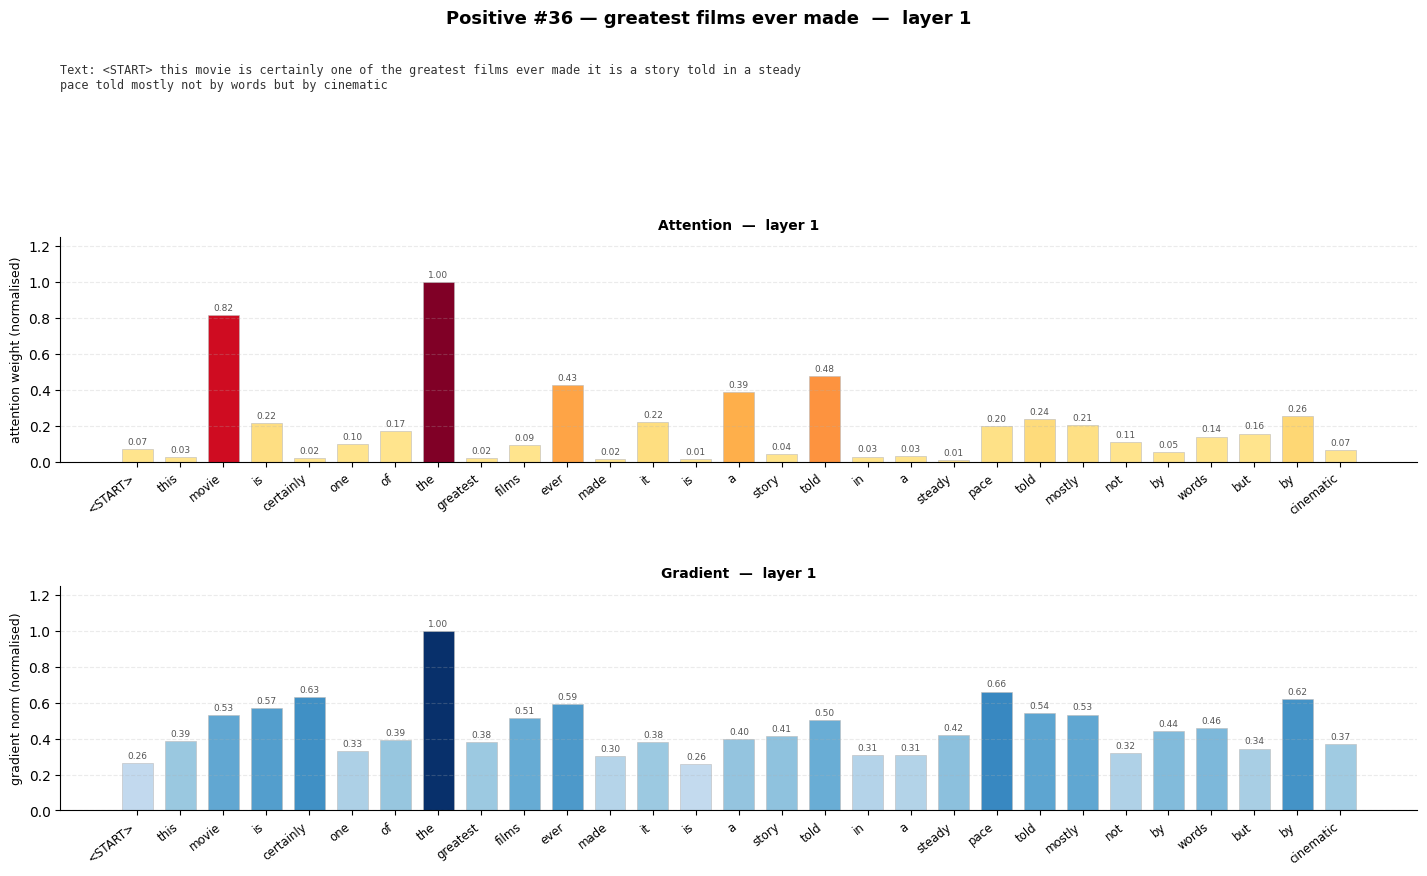

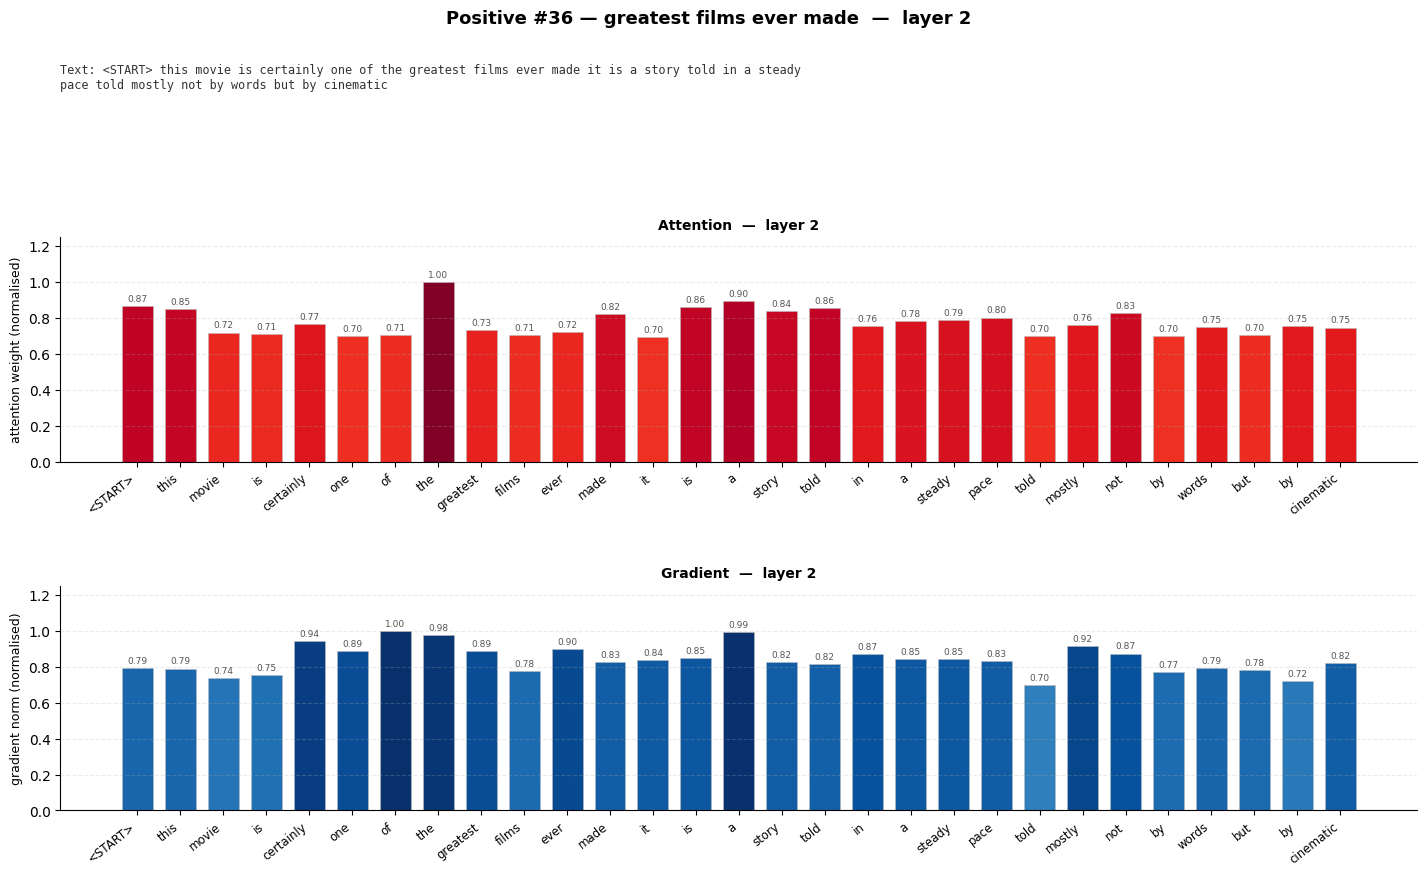

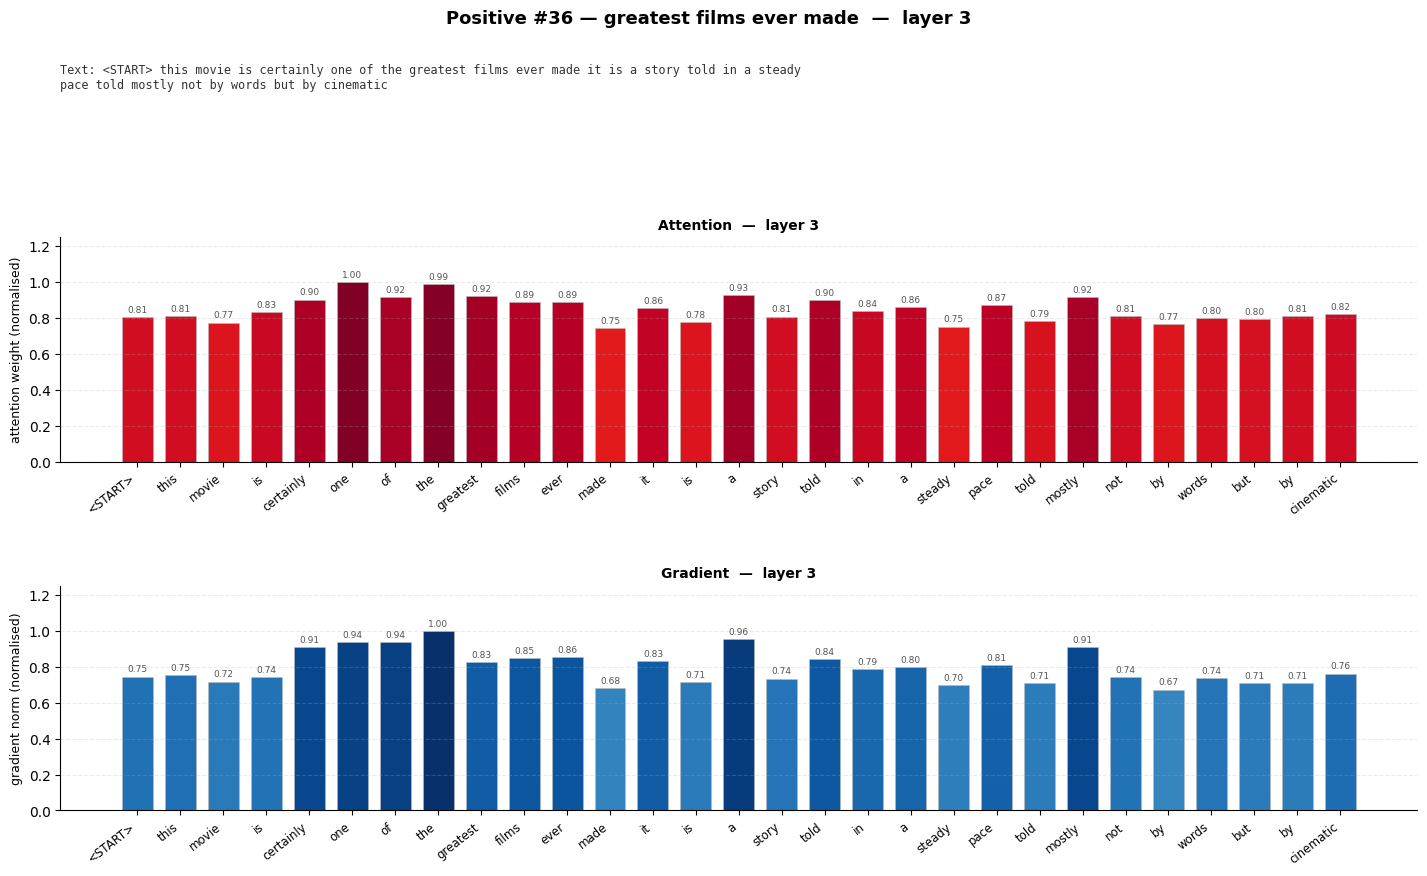

In [30]:
def run_sentence(model, seq, label, device=DEVICE, max_words=30, print_text=True):
    print("=" * 70)
    print(label)
    print("=" * 70)
    for layer_idx in [0, 1, 2]:
        tokens, attn, grad = analyze_sentence(
            model, seq, layer_idx=layer_idx, max_words=max_words, device=device)

        attn_np = attn.detach().numpy()
        attn_np = attn_np / (attn_np.max() + 1e-8)
        grad_np = grad.detach().numpy()

        if print_text:
            print(f"\n  layer {layer_idx + 1}")
            print(f"  {'token':<20} {'attn':>6}  {'grad':>6}")
            print(f"  {'-'*36}")
            for tok, a, g in zip(tokens, attn_np, grad_np):
                print(f"  {tok:<20} {a:>6.3f}  {g:>6.3f}")

        plot_importance(tokens, attn, grad,
                        title=f'{label}  —  layer {layer_idx + 1}',
                        layer_idx=layer_idx)
    print()


run_sentence(model, x_test[36], 'Positive #36 — greatest films ever made', print_text=False)


- warstwa 1: attention skupia się na "the" (1.00) i "movie" (0.82) — "the" to słowo funkcyjne, więc attention niekoniecznie trafia w semantykę
- warstwa 1: gradient równomierny (0.3-0.6 wszędzie) — żadne słowo wyraźnie nie dominuje
- warstwy 2-3: attention całkowicie się spłaszcza (wszystko 0.7-1.0) — traci selektywność, model przestaje "wybierać"
gradient w warstwach 2-3 też wyrównany — obie metody przestają dawać użyteczną informację w głębszych warstwach

Negative #39 — boring and quite stupid


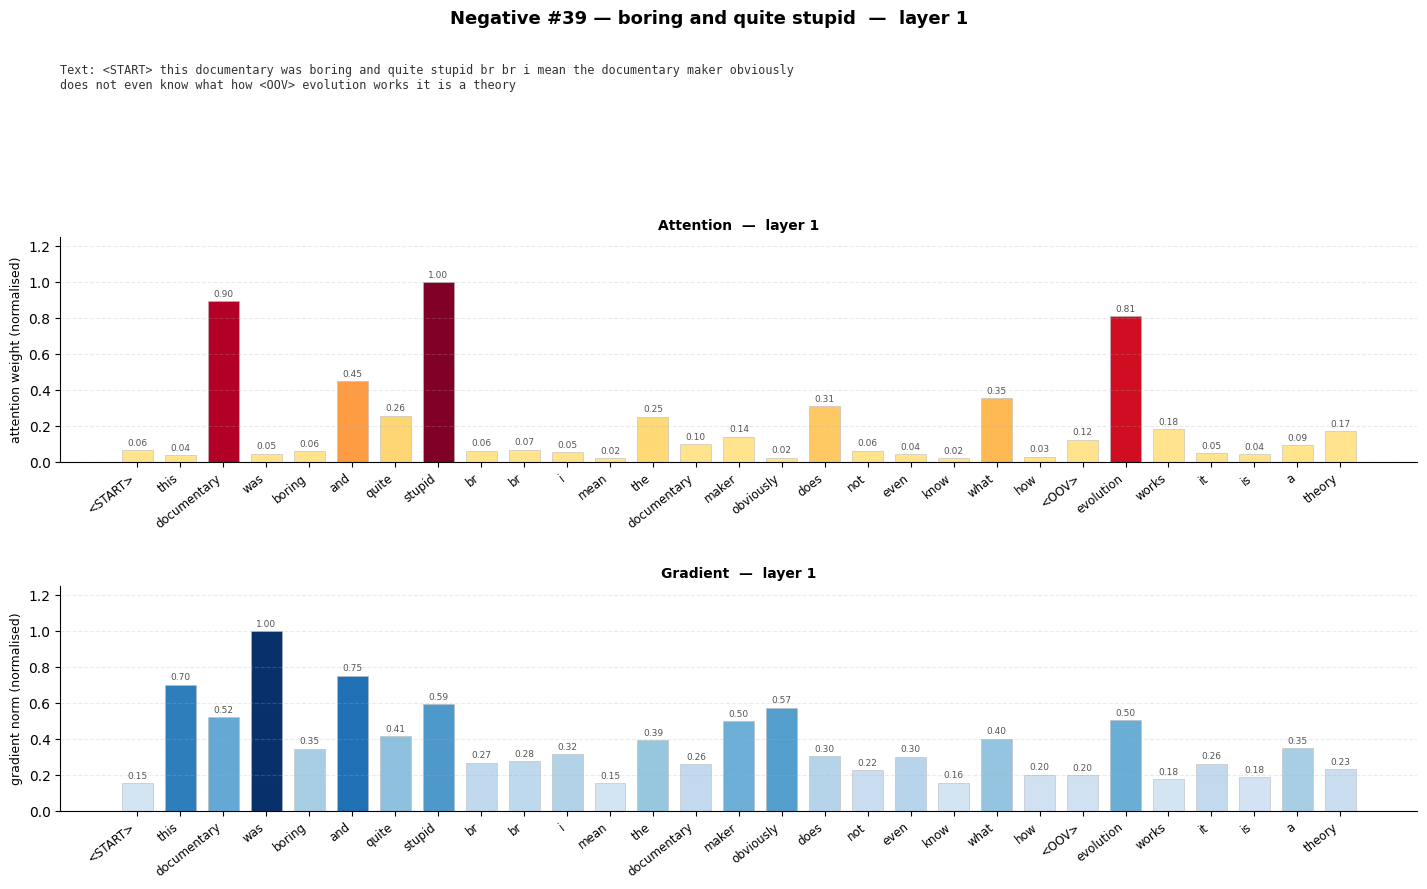

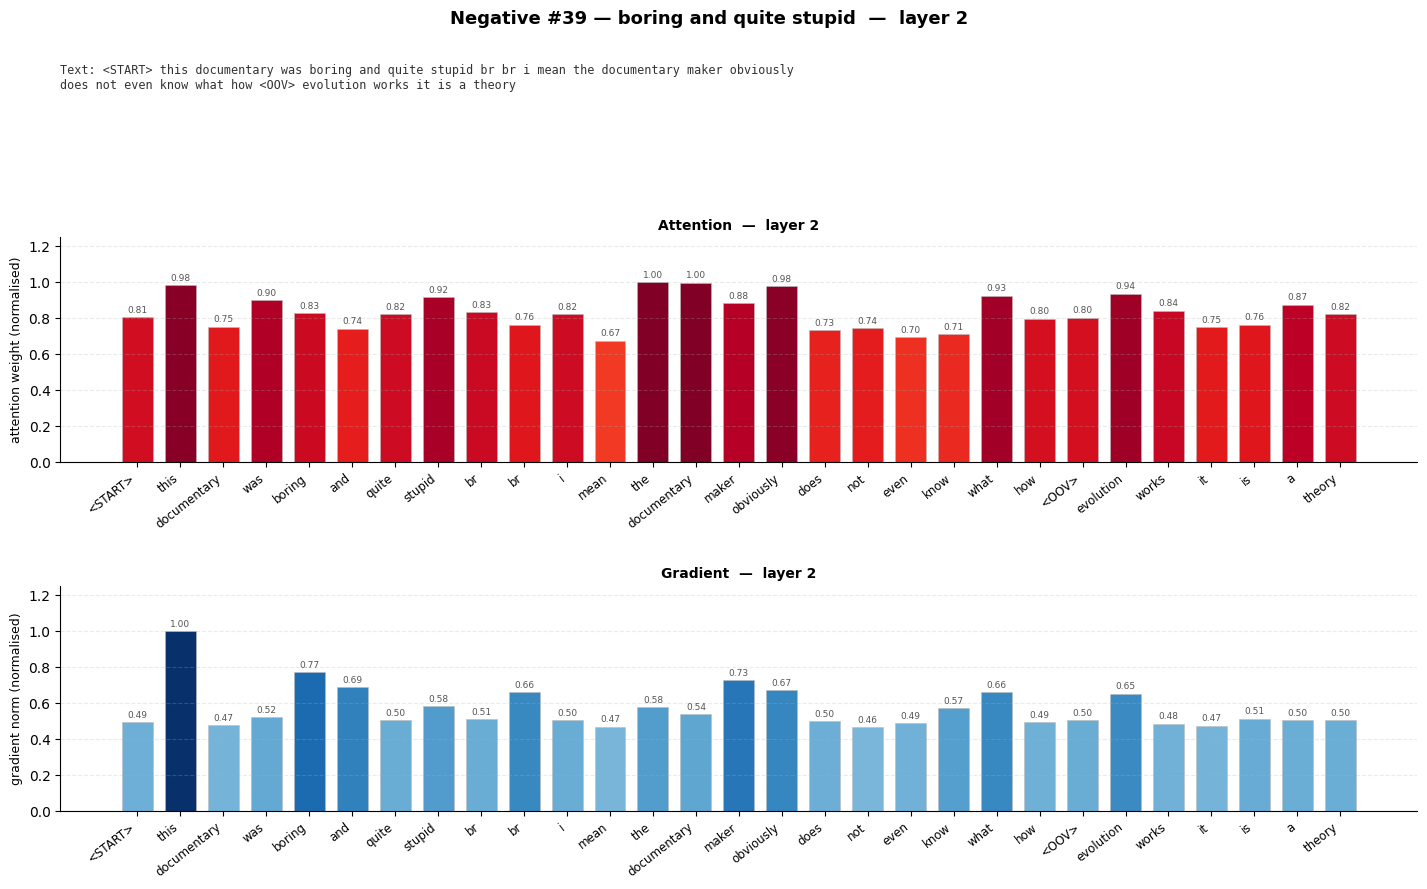

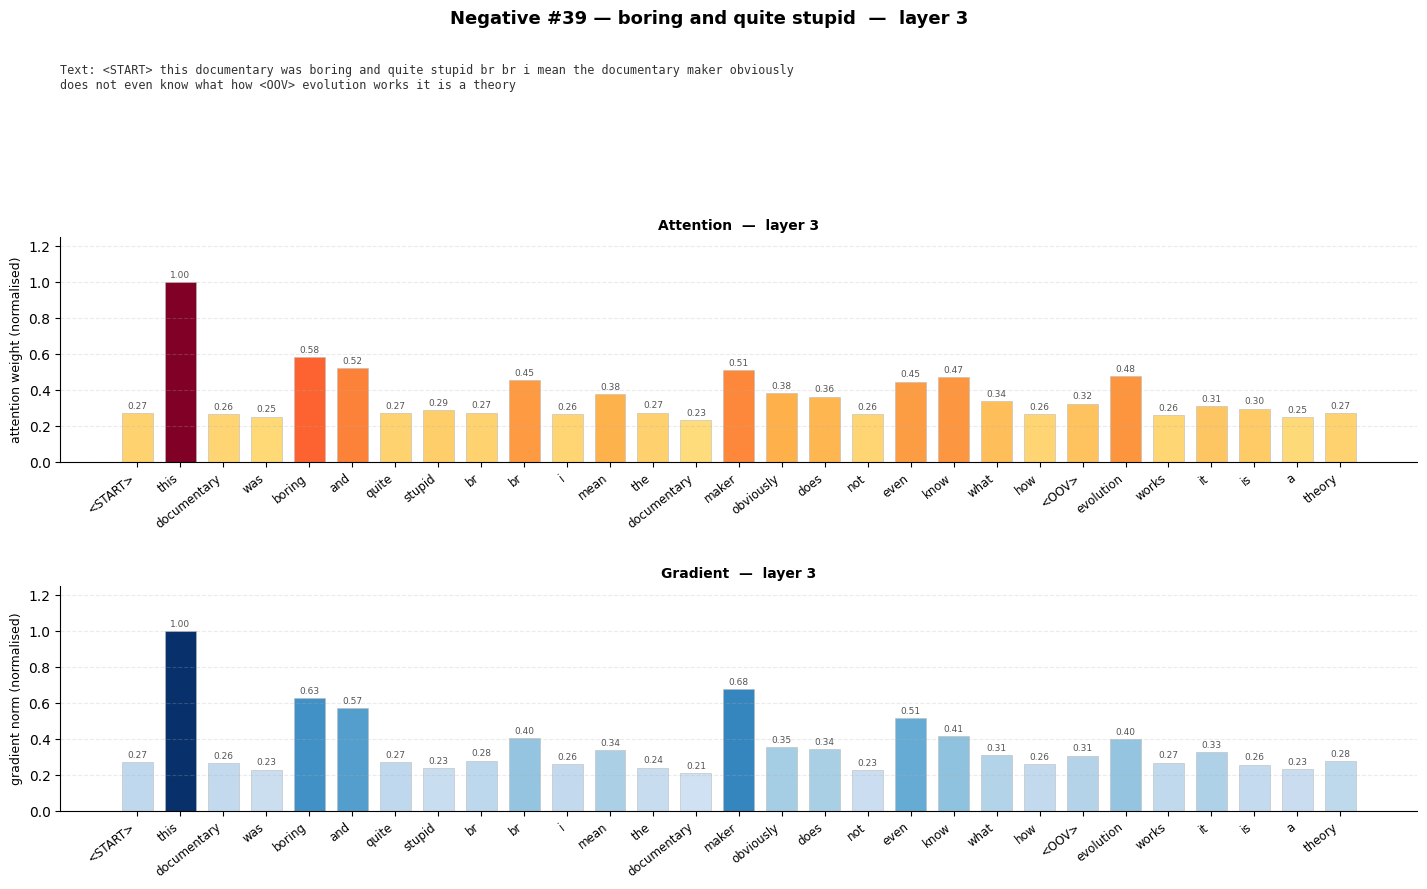

In [31]:
run_sentence(model, x_test[39], 'Negative #39 — boring and quite stupid', print_text=False)

- warstwa 1: attention selektywna i sensowna — "documentary" (0.90), "stupid" (1.00), "evolution" (0.81) to faktyczne sygnały negatywne
- warstwa 1: gradient uderza w "was" (1.00) — attention i gradient wskazują różne rzeczy, gradient reaguje na strukturę zdania bardziej niż na semantykę
- warstwy 2-3: ten przykład spłaszcza się wolniej niż pozytywny — warstwa 3 attention nadal ma pewną selektywność ("this" 1.00, "boring" 0.58)

Misclassified #5 — disgusted (but positive!)


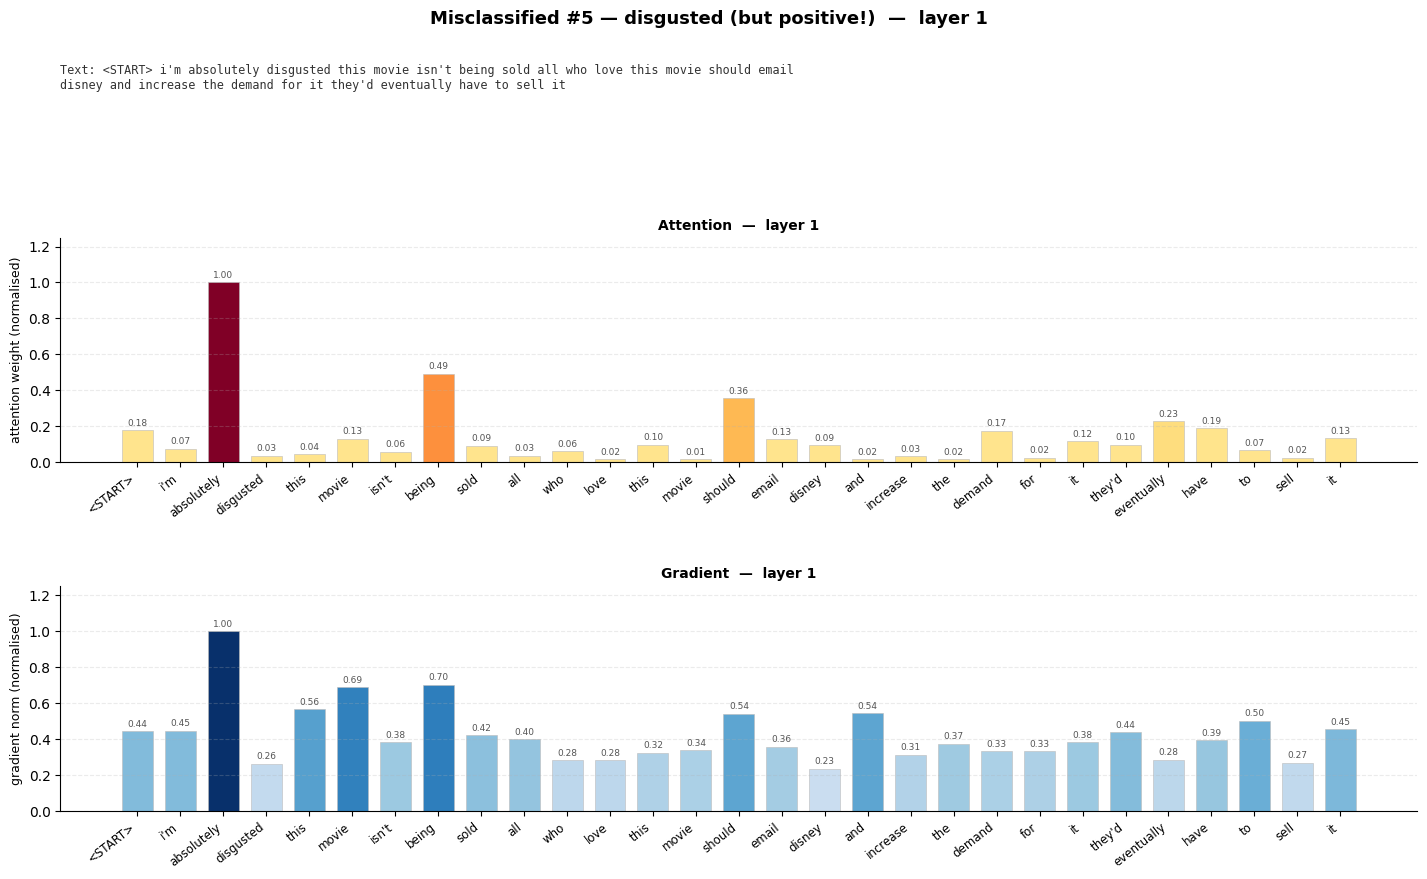

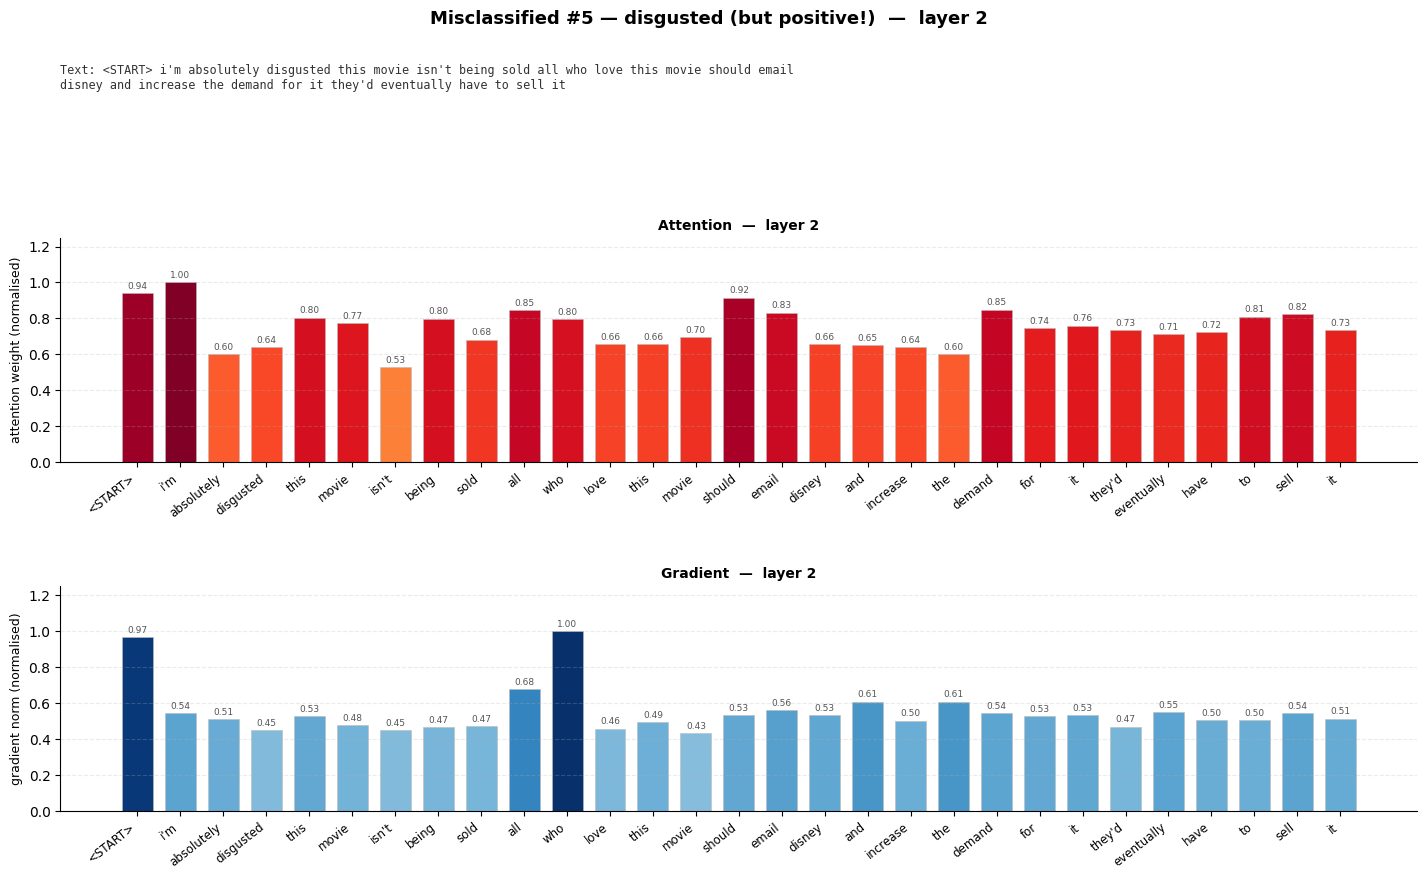

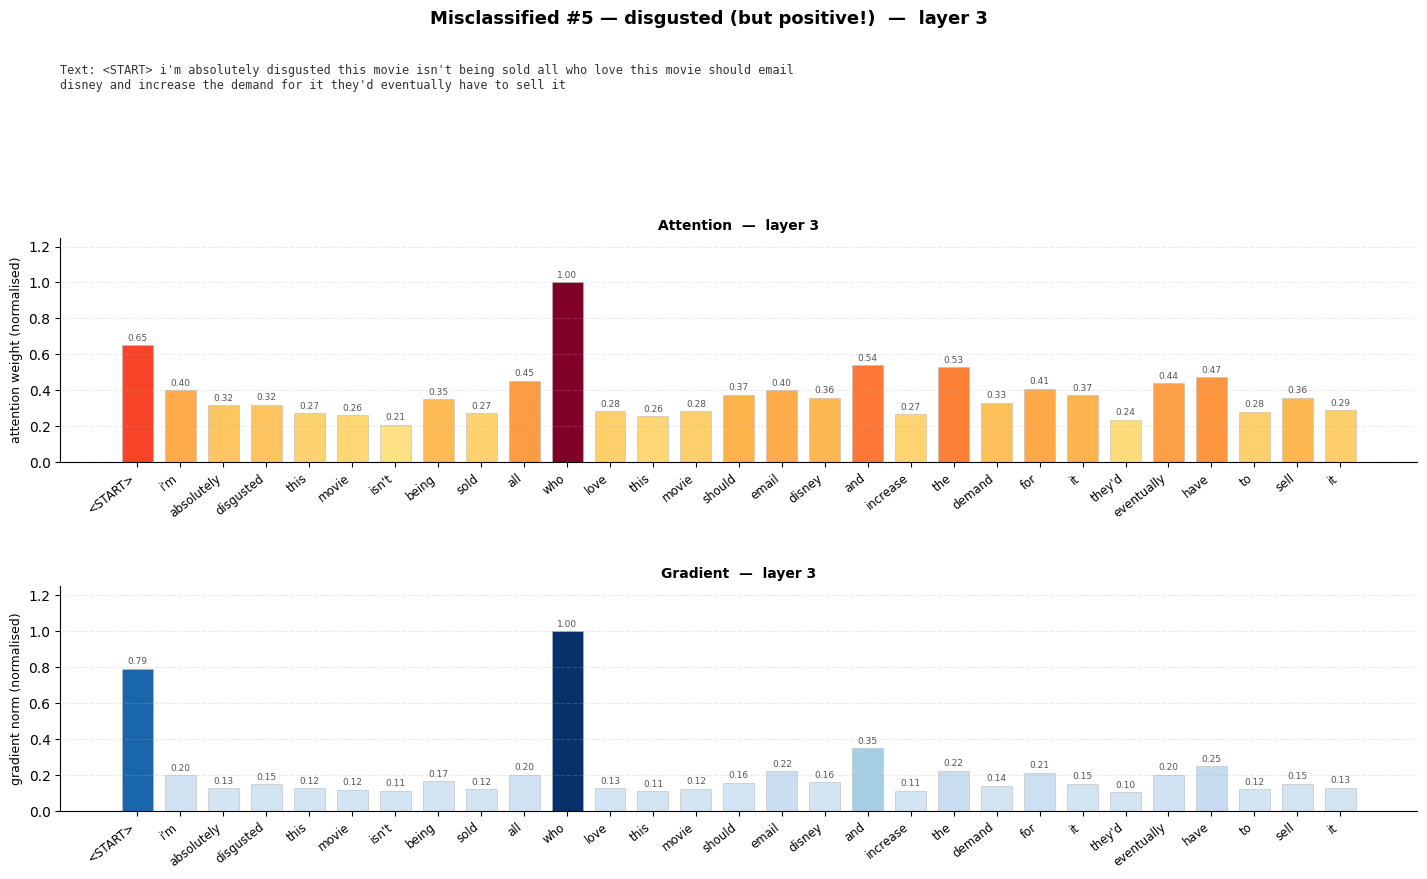

In [23]:
run_sentence(model, x_test[5], 'Misclassified #5 — disgusted (but positive!)', print_text=False)

- warstwa 1: attention uderza w "absolutely" (1.00), gradient też (1.00) — pełna zgodność, model pewnie klasyfikuje jako negatywne
- warstwa 2: gradient przesuwa się na <START> (0.97) i "who" (1.00) — model zaczyna łapać "all who love" ale attention nadal widzi negatywny kontekst
- warstwa 3: attention i gradient zgodnie wskazują "who" (1.00) — model w ostatniej warstwie skupia się na właściwym fragmencie, ale klasyfikacja już była błędna — to dobry przykład że wyjaśnialność przez attention nie zawsze odzwierciedla rzeczywisty powód decyzji

## Zadanie 1 - insects

In [40]:
from aeon.datasets import load_classification
X, y = load_classification("InsectWingbeat", extract_path="insect_data")

In [41]:
from sklearn.preprocessing import LabelEncoder

print(type(X))
print(len(X))
print(type(X[0]))
print(X[0].shape)
print(y[:5])
print(set(y))
print(len(set(y)))

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(y_encoded[:5])
print(le.classes_)

max_features = max(x.shape[1] for x in X)
print(max_features)

X_arr = np.zeros((len(X), 200, max_features), dtype=np.float32)
for i, x in enumerate(X):
    X_arr[i, :, :x.shape[1]] = x

print(X_arr.shape)


<class 'numpy.ndarray'>
50000
<class 'numpy.ndarray'>
(200, 20)
['aedes_female' 'aedes_female' 'aedes_female' 'aedes_female'
 'aedes_female']
{np.str_('aedes_female'), np.str_('quinx_female'), np.str_('tarsalis_female'), np.str_('house_flies'), np.str_('stigma_male'), np.str_('fruit_flies'), np.str_('stigma_female'), np.str_('quinx_male'), np.str_('aedes_male'), np.str_('tarsalis_male')}
10
[0 0 0 0 0]
['aedes_female' 'aedes_male' 'fruit_flies' 'house_flies' 'quinx_female'
 'quinx_male' 'stigma_female' 'stigma_male' 'tarsalis_female'
 'tarsalis_male']
20
(50000, 200, 20)


In [42]:
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# padding do max_features
max_features = max(x.shape[1] for x in X)
X_arr = np.zeros((len(X), 200, max_features), dtype=np.float32)
for i, x in enumerate(X):
    X_arr[i, :, :x.shape[1]] = x

print(f"X_arr shape: {X_arr.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_encoded, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)}  Test: {len(X_test)}")

class InsectDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE_INSECT = 64

train_insect = DataLoader(InsectDataset(X_train, y_train),
                          batch_size=BATCH_SIZE_INSECT, shuffle=True)
test_insect  = DataLoader(InsectDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE_INSECT, shuffle=False)

X_arr shape: (50000, 200, 20)
Train: 40000  Test: 10000


In [43]:
class InsectTransformer(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers,
                 num_classes, max_len=201, dropout=0.1):
        super().__init__()

        self.input_proj    = nn.Linear(input_size, d_model)
        self.cls_token     = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                  num_layers=num_layers)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape

        x = self.input_proj(x)

        cls_token = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_token, x], dim=1)

        positions = torch.arange(seq_len + 1, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, -1)
        x = x + self.pos_embedding(positions)

        x = self.dropout(x)
        x = self.transformer(x)

        return self.classifier(x[:, 0, :])

In [44]:
import os
from torch.optim import Adam
import matplotlib.pyplot as plt

def train_insect_model(model, train_loader, val_loader,
                       epochs=10, lr=1e-3, device='cpu'):
    model.to(device)
    optimizer     = Adam(model.parameters(), lr=lr)
    criterion     = nn.CrossEntropyLoss()
    history       = {'train_loss': [], 'train_acc': [],
                     'val_loss':   [], 'val_acc':   []}
    best_val_loss = float('inf')
    os.makedirs('models', exist_ok=True)

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for x, labels in train_loader:
            x, labels = x.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for x, labels in val_loader:
                x, labels   = x.to(device), labels.to(device)
                outputs     = model(x)
                loss        = criterion(outputs, labels)
                val_loss   += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc  = val_correct / val_total

        for k, v in zip(['train_loss', 'train_acc', 'val_loss', 'val_acc'],
                        [train_loss,   train_acc,   val_loss,   val_acc]):
            history[k].append(v)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'models/insect_transformer_best.pt')
            best_str = '  ← best'
        else:
            best_str = ''

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}{best_str}")

    print(f"\nBest val loss: {best_val_loss:.4f} → models/insect_transformer_best.pt")
    return history


Parametry: 624,650
Epoch 1/10 | Train loss: 1.2941, acc: 0.4914 | Val loss: 0.9547, acc: 0.6136  ← best
Epoch 2/10 | Train loss: 0.9492, acc: 0.6170 | Val loss: 0.8858, acc: 0.6349  ← best
Epoch 3/10 | Train loss: 0.8967, acc: 0.6375 | Val loss: 0.8736, acc: 0.6443  ← best
Epoch 4/10 | Train loss: 0.8592, acc: 0.6529 | Val loss: 0.8677, acc: 0.6652  ← best
Epoch 5/10 | Train loss: 0.8347, acc: 0.6626 | Val loss: 0.8460, acc: 0.6604  ← best
Epoch 6/10 | Train loss: 0.8169, acc: 0.6716 | Val loss: 0.8168, acc: 0.6701  ← best
Epoch 7/10 | Train loss: 0.8006, acc: 0.6764 | Val loss: 0.7988, acc: 0.6764  ← best
Epoch 8/10 | Train loss: 0.7914, acc: 0.6787 | Val loss: 0.8310, acc: 0.6606
Epoch 9/10 | Train loss: 0.7826, acc: 0.6852 | Val loss: 0.7826, acc: 0.6893  ← best
Epoch 10/10 | Train loss: 0.7754, acc: 0.6891 | Val loss: 0.7949, acc: 0.6804

Best val loss: 0.7826 → models/insect_transformer_best.pt


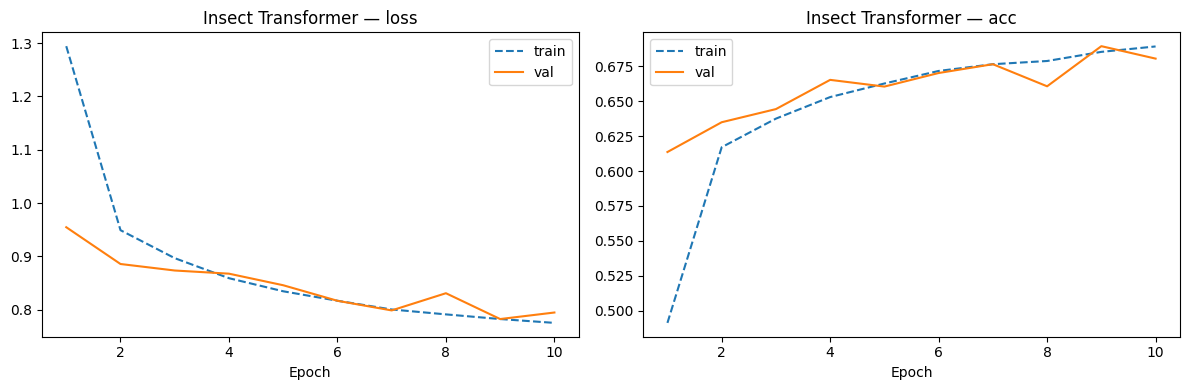

In [45]:

insect_model = InsectTransformer(
    input_size=X_arr.shape[2], d_model=128, nhead=8,
    num_layers=3, num_classes=10, dropout=0.05
)
print(f"Parametry: {sum(p.numel() for p in insect_model.parameters()):,}")

h_insect = train_insect_model(
    insect_model, train_insect, test_insect,
    epochs=10, lr=1e-3, device=DEVICE
)


plot_history(h_insect, title='Insect Transformer')
